In [1]:
%load_ext autoreload
%autoreload 2

## Evaluación de modelos


### Modelo ingenuo

Añadimos la raíz del proeycto a la ruta de modulos ya que Jupyter arranca dentro de Notebooks y desde ahí no vel el paquete src

In [2]:
import sys
from pathlib import Path
RAIZ = Path.cwd().parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

Reconstruimos el dataset a partir del csv y aplicamos la partición y la normalización, dejando el dataset listo para modelar.

In [3]:
# --- Librerías ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Módulos del proyecto ---
from src.features import construir_dataset
from src.splits import particionar, normalizar
from src.evaluacion import evaluar, tabla_resultados

df = construir_dataset()
partes = particionar(df)
partes_norm, est = normalizar(partes)

[data] Caché local: GSPC_2000-01-01_2026-09-01.csv
[features] 6705 filas -> 6678 tras eliminar NaN
[features] Guardado en C:\Users\Victor\Desktop\Victor\Matematicas\neuro-fuzzy-volatility-forecasting\data\processed\dataset.csv
[splits] train  :  3998 filas  (2000-02-03 → 2015-12-23)
[splits] val    :  1001 filas  (2016-01-04 → 2019-12-23)
[splits] test   :  1669 filas  (2020-01-02 → 2026-08-24)
[splits] estres :    52 filas  (2020-02-18 → 2020-04-30)


**Evaluación del modelo ingenuo**

In [4]:
from src.evaluacion import evaluar, tabla_resultados
from src.modelos_ingenuos import predecir_ingenuo

# Usamos `partes`, no `partes_norm`: los ingenuos no se entrenan y
# trabajan en escala original.
test = partes["test"]
idx_estres = partes["estres"].index
y_test = test["y"]

filas = [evaluar(y_test, predecir_ingenuo(test, col), idx_estres, nombre)
         for col, nombre in [("rv_1", "Ingenuo 1d"),
                             ("rv_5", "Ingenuo 5d"),
                             ("rv_22", "Ingenuo 22d")]]

tabla = tabla_resultados(filas)
tabla.to_csv("../results/tables/e1_ingenuos.csv")
tabla

,RMSE,MAE,QLIKE,RMSE_tranq,MAE_tranq,QLIKE_tranq,RMSE_estres,MAE_estres,QLIKE_estres
modelo,,,,,,,,,
Ingenuo 22d,0.1094,0.0648,0.1211,0.0792,0.0549,0.1130,0.4347,0.3721,0.3725
Ingenuo 5d,0.1002,0.0637,0.1680,0.0846,0.0580,0.1619,0.3151,0.2413,0.3593
Ingenuo 1d,0.1410,0.0967,8.5075,0.1239,0.0902,8.7350,0.4008,0.2995,1.4337


Conclusiones de la evaluación:

1. El ingenuo de día 1 es inservible. Obtenemos un QLIKE de 8.5 frente a 0,12 y 0.17 de los otros. El problema es que con días con cierre casi plano, la predicción $\hat{y}$, al ser cociente, dispara el error. RMSE y MAE apenas lo penalizan, por lo que se muestra porque QLIKE es la métrica adecuada
2. El ranking depende de la métrica. El de 22 días gana en QLIKE (0,121 vs 0,168), pero el de 5 días gana en RMSE (0,100 vs 0,109) y en el periodo de estrés (RMSE 0,315 vs 0,435). Como conclusión, podemos sacar que la ventana larga (22) gana en estabilidad y evita errores grandes en calma,pero en situaciones de estres no funciona tan bien como la ventana de 5 días.
3. Se observa un patrón importante: si comparamos el RMSE global (22 días)  y el RMSE tranquilo, se observa que ambos son muy parecidos (0.1 frente a 0.11). Se podría decir que el modelo funciona correctamente. Pero en cambio en períodos de estres se obtiene un RSME de 0.43 , es decir esta multipliando por 4 su error.

De los puntos 2 y 3 extraemos una conclusión muy valiosa para el futuro. En nuestro estudio estamos intentando predecir el valor de la volatilidad. Esta predicción es especialmente útil, el la vida real, para predecir escenarios de estres con volatilidades altas y preparase ante ellas. Es por eso que nos interesa generar un modelo que se adapte muy bien ante estas sitauciones en vez de uno que prediga muy bien estados de calma pero falle mucho en situaciones de volatidilad extrema. COn esto podemos extraer que:
- Que es mejor una ventana corta de 5 días que una ventan larga, ya que la ventan larga predicira mejor sitauciones de calma pero la ventan corta es mejor en situaciones de estres
- Es importante valorar el modelo no solo en conjuntos globales, sino también en conjuntos de estres para optimizar la utilidad en la vida real

### Modelo HAR

Entrenamos con train por MCO. Primero de todo recordamos como se comento en la nota correspondiente que el reparto de la multicolinealidad no es un reparto exacto debido a la alta correalción entre las ventanas.

Aún asñu podemos observar como la escala mensual domina (0.56), frente a la escala semanal (0,26). La escala diaria es irrelevante (es demasiado ruidos y las otras dos escalas ya contienen su información)

In [5]:
from src.har import entrenar_har, predecir_har


har = entrenar_har(partes["train"])
print(har.summary().tables[1])
print(f"\nR² dentro de muestra: {har.rsquared:.4f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4045      0.028    -14.342      0.000      -0.460      -0.349
log_rv_1   -8.464e-05      0.006     -0.014      0.989      -0.012       0.011
log_rv_5       0.2648      0.020     13.135      0.000       0.225       0.304
log_rv_22      0.5605      0.024     23.621      0.000       0.514       0.607

R² dentro de muestra: 0.4679


**HAR gana en las tres métricas globales** por muy poco. Esto nos dice que la diferencia entre copiar el pasado y el modelo HAR apenas contiene diferencias reales. Es la constatación de cuanta señal hay en la persistencia de la volatilidad, fijando así un listón realista para ANFIS.

Conclusión: todo modelo posterior debe batir el **QLIKE = 0,1131**

In [6]:
y_hat_har = predecir_har(har, test)

filas.append(evaluar(y_test, y_hat_har, idx_estres, "HAR"))
tabla = tabla_resultados(filas)
tabla.to_csv("../results/tables/e3_har.csv")
tabla

,RMSE,MAE,QLIKE,RMSE_tranq,MAE_tranq,QLIKE_tranq,RMSE_estres,MAE_estres,QLIKE_estres
modelo,,,,,,,,,
HAR,0.0968,0.0549,0.1131,0.0717,0.0483,0.1045,0.3757,0.2606,0.3799
Ingenuo 22d,0.1094,0.0648,0.1211,0.0792,0.0549,0.1130,0.4347,0.3721,0.3725
Ingenuo 5d,0.1002,0.0637,0.1680,0.0846,0.0580,0.1619,0.3151,0.2413,0.3593
Ingenuo 1d,0.1410,0.0967,8.5075,0.1239,0.0902,8.7350,0.4008,0.2995,1.4337


Observamos las diferencias entre los valores observados, los predichos por el modelo ingenuo y los predichos por el modelo HAR.

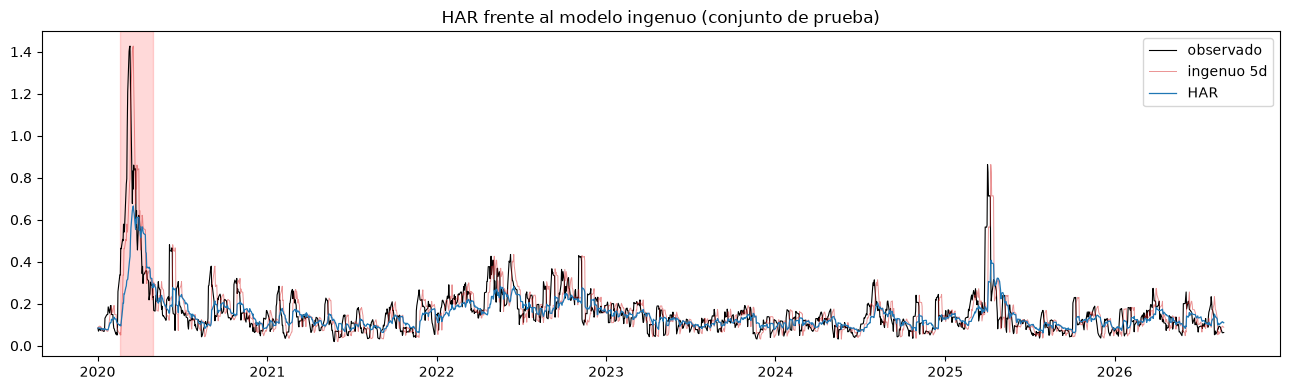

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, y_test, lw=0.8, color="black", label="observado")
ax.plot(test.index, predecir_ingenuo(test, "rv_5"), lw=0.7,
        color="tab:red", alpha=0.5, label="ingenuo 5d")
ax.plot(test.index, y_hat_har, lw=0.9, color="tab:blue", label="HAR")
ax.axvspan(idx_estres.min(), idx_estres.max(), color="red", alpha=0.15)
ax.set_title("HAR frente al modelo ingenuo (conjunto de prueba)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/e3_har.png", dpi=150)
plt.show()

In [8]:
resid = har.resid
print(f"Media de los residuos: {resid.mean():.2e}   (MCO la fuerza a 0)")
print(f"Autocorrelación en el retardo 1: {resid.autocorr(1):.3f}")
print(f"Autocorrelación en el retardo 5: {resid.autocorr(5):.3f}")

Media de los residuos: 1.58e-15   (MCO la fuerza a 0)
Autocorrelación en el retardo 1: 0.763
Autocorrelación en el retardo 5: -0.029


### Modelo Redes Neuronales

Se observa como se detiene el etrenamiento en la parada 151. Como fijamos 100 epocas seguidas de no mejoras para parar, entonces la época en donde se cumplio es la 51. Aún parando en la 151, nos hemos quedado con los pesos de la parada 51.

El output muestra nuestros 41 parametros que hemos definicdo previamente. Esto ha sido definido así para que tenga un tamaño parecido a las 27 reglas del ANFIS, y que el abuso de los parametros no influya en la decisión de que modelo es mejor.

In [9]:
from src.mlp import entrenar_mlp, predecir_mlp

# Hemos de introducir partes normalizadas ya que sino el descenso de gradiente
# converge mal si las variables tienen escalas dispares.
mlp, hist = entrenar_mlp(partes_norm["train"], partes_norm["val"])

[mlp] Parada temprana en la época 151
[mlp] MSE de validación: 0.26357 | parámetros: 41


En la gráfica de a continuación podemos extraer varias conclusiones:
1. Las dos curvas (train y test), bajan juntas hasta la época 40 aproximadamente, es decir la red esta aprendiendo.
2. A partir de la 51 se separan, lo que nos dice que la red ha dejado de aprender y ha empezado a memorizar el ruido concreto de los datos de entrenamiento.
3. Las dos curvas quedan muy juntas lo que es un excelente indicador de que el sobreajuste es leve

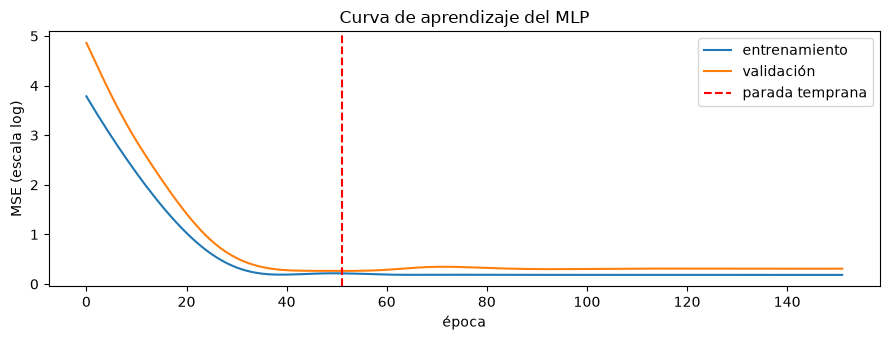

In [10]:
h = np.array(hist)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(h[:, 0], label="entrenamiento")
ax.plot(h[:, 1], label="validación")
ax.axvline(h[:, 1].argmin(), color="red", ls="--", label="parada temprana")
ax.set_xlabel("época"); ax.set_ylabel("MSE (escala log)")
ax.set_title("Curva de aprendizaje del MLP")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/e4_curva_aprendizaje.png", dpi=150)
plt.show()

El MLP no mejora a HAR en nada: RMSE 0,1024 frente a 0,0968, QLIKE 0,1418 frente a 0,1131. Es más, queda por detrás incluso del ingenuo mensual, y es el peor de todos en el periodo de estrés.

Esto no lo hemos de ver como un fallo del experimento sino como un resultado interesante:
- La NO linealidad no nos aporta nada en nuestro caso de estudio, es decir: la relación entre las volatilidades pasadas y la futura, en escala logarítmica, es prácticamente una recta, y añadir capacidad para curvarse no ayuda.


Y lo más interesante de todo es como condiciona a los futuros resultados de ANFIS. Si ANFIS mejorase a HAR, ya no podríamos decir que es **porque es no lineal**, porque con MLP acabamos de demostrar que ese camino no funciona correctamente con estos datos. Entonces no nos quedaría otra opción que atribuirlo a la partición difusa.

In [11]:
# Predecimos sobre partes_norm["test"], que tiene las mismas entradas
# normalizadas con los estadísticos de train.
y_hat_mlp = predecir_mlp(mlp, partes_norm["test"])

filas.append(evaluar(y_test, y_hat_mlp, idx_estres, "MLP (3-8-1)"))
tabla = tabla_resultados(filas)
tabla.to_csv("../results/tables/e4_mlp.csv")
tabla

,RMSE,MAE,QLIKE,RMSE_tranq,MAE_tranq,QLIKE_tranq,RMSE_estres,MAE_estres,QLIKE_estres
modelo,,,,,,,,,
HAR,0.0968,0.0549,0.1131,0.0717,0.0483,0.1045,0.3757,0.2606,0.3799
Ingenuo 22d,0.1094,0.0648,0.1211,0.0792,0.0549,0.1130,0.4347,0.3721,0.3725
MLP (3-8-1),0.1024,0.0576,0.1418,0.0760,0.0505,0.1313,0.3960,0.2779,0.4683
Ingenuo 5d,0.1002,0.0637,0.1680,0.0846,0.0580,0.1619,0.3151,0.2413,0.3593
Ingenuo 1d,0.1410,0.0967,8.5075,0.1239,0.0902,8.7350,0.4008,0.2995,1.4337


Observamos las diferencias entre los valores observados, los predichos por HAR y MLP.

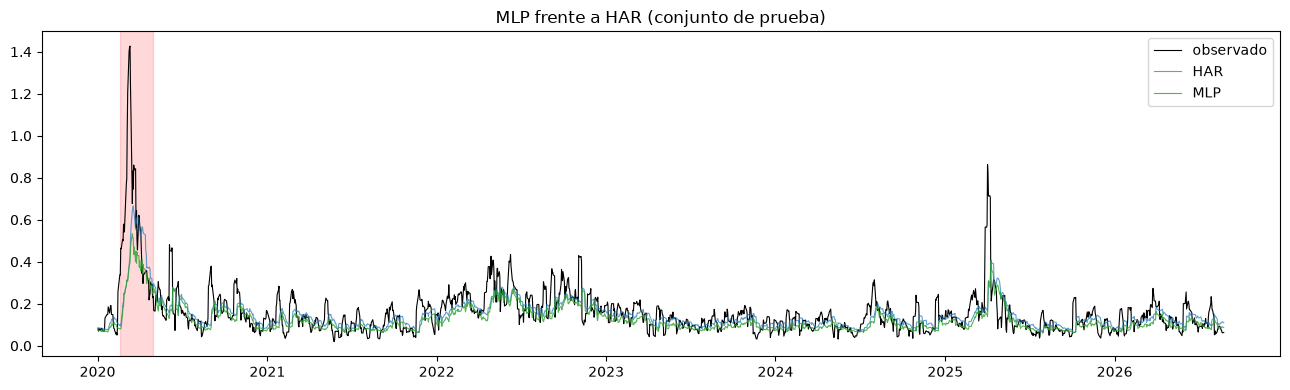

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, y_test, lw=0.8, color="black", label="observado")
ax.plot(test.index, y_hat_har, lw=0.8, color="tab:blue", alpha=0.7, label="HAR")
ax.plot(test.index, y_hat_mlp, lw=0.8, color="tab:green", alpha=0.8, label="MLP")
ax.axvspan(idx_estres.min(), idx_estres.max(), color="red", alpha=0.15)
ax.set_title("MLP frente a HAR (conjunto de prueba)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/e4_mlp.png", dpi=150)
plt.show()

### ANFIS

#### Funciones de pertenencia

En estas celdas se prueba la capa 1 de ANFIS con parámetros puestos a mano: tres campanas centradas en −3, −2 y −1, que representan los conceptos baja, media y alta sobre la variable $log \ RV^{1}$. Al evaluar el valor −2 se obtienen los grados [0,329, 1, 0,329]: pertenece por completo al conjunto media, cuyo centro es exactamente ese punto, y en grado 0,33 a los otros dos, por estar equidistante de ambos.

Lo relevante es que los tres grados son no nulos y no suman uno. Un mismo día pertenece simultáneamente a varios conjuntos, en distinta medida, lo que confirma que estamos ante grados de pertenencia y no ante probabilidades. Es precisamente ese solapamiento el que permitirá que varias reglas se activen a la vez y que la predicción varíe de forma continua al desplazarse por el espacio de entrada.

In [13]:
import torch
from src.anfis import CapaPertenencia

# Prueba con parámetros puestos a mano, solo para ver la forma.
capa = CapaPertenencia(n_entradas=3, n_conjuntos=3)
with torch.no_grad():
    capa.c[:] = torch.tensor([[-3., -2., -1.]] * 3)   # tres centros
    capa.a[:] = 0.7
    capa.log_b[:] = 0.0                                # b = 1

x = torch.tensor([[-2.0, -2.0, -2.0]])
mu = capa(x)
print("Forma de la salida:", mu.shape)      # (1, 3, 3)
print("Grados de la variable 1:", mu[0, 0].detach().numpy().round(3))

Forma de la salida: torch.Size([1, 3, 3])
Grados de la variable 1: [0.329 1.    0.329]


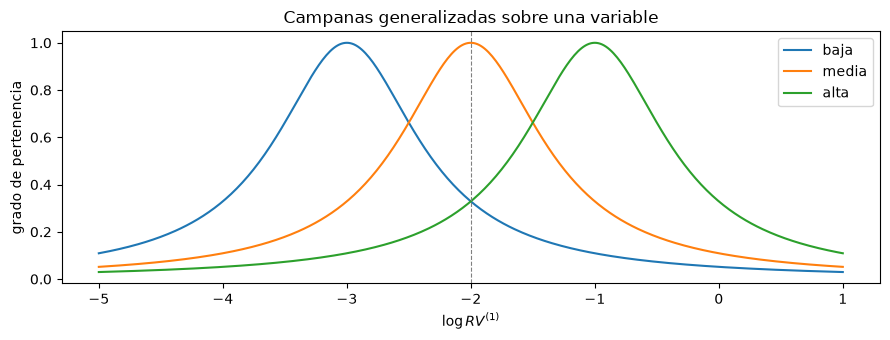

In [14]:
xs = torch.linspace(-5, 1, 400).unsqueeze(1).repeat(1, 3)
mus = capa(xs).detach().numpy()

fig, ax = plt.subplots(figsize=(9, 3.5))
for j, etiqueta in enumerate(["baja", "media", "alta"]):
    ax.plot(xs[:, 0], mus[:, 0, j], label=etiqueta)
ax.axvline(-2.0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("$\\log RV^{(1)}$"); ax.set_ylabel("grado de pertenencia")
ax.set_title("Campanas generalizadas sobre una variable")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/e5_pertenencia_ejemplo.png", dpi=150)
plt.show()

### Inferencia hacia delante

A continuación podemos confirmar que hemos montado el modelo correctamente y la estructura es correcta.

- 27 reglas y 135 parámetros, es decir los números previstos: 27 de premisa (a, b, c por cada uno de los 9 conjuntos) y 108 de consecuente (4 por regla, ya que cada regla tendrá su propia recta).
- Pesos de forma (5, 27): para cada uno de los 5 días, un peso por regla.
- Suman 1 en todas las filas: la capa 3 normaliza correctamente.

In [16]:
from src.anfis import ANFIS, ENTRADAS

modelo = ANFIS(n_entradas=3, n_conjuntos=3)
print(f"Reglas: {modelo.n_reglas}")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters())}")

# Pasada de prueba con 5 días reales del conjunto de entrenamiento.
X = torch.tensor(partes_norm["train"][ENTRADAS].values[:5], dtype=torch.float32)
w = modelo.pesos_reglas(X)

print(f"\nForma de los pesos: {w.shape}")
print(f"¿Suman 1? {w.sum(dim=1).detach().numpy().round(6)}")
print(f"Salida: {modelo(X).detach().numpy().round(4)}")

Reglas: 27
Parámetros: 135

Forma de los pesos: torch.Size([5, 27])
¿Suman 1? [1. 1. 1. 1. 1.]
Salida: [0. 0. 0. 0. 0.]


In [17]:
w_np = w.detach().numpy()
print("Reglas con peso > 0.01 por día:", (w_np > 0.01).sum(axis=1))
print("Peso de la regla dominante:", w_np.max(axis=1).round(3))

Reglas con peso > 0.01 por día: [27 27 27 27 27]
Peso de la regla dominante: [0.037 0.037 0.037 0.037 0.037]


### Inicialización

A continuación inicializamos el modelos. Centros, luego una fila por variable y las tres columnas (baja/media/alta):

- log RV(1):   -1,216   0,150   1,054
- log RV(5):   -1,245  -0,008   1,250
- log RV(22):  -1,166  -0,094   1,354

Se puede leer como que baja es aproximadamente 1,2 desviaciones por debajo de la media, media aproximadamanet esta en la media y alta 1,2 por encima de la media

In [18]:
from src.anfis import inicializar_por_percentiles
from src.har import entrenar_har

# OJO: ANFIS trabaja con entradas normalizadas, así que necesitamos los
# coeficientes de HAR ajustado sobre ESAS mismas entradas, no sobre las
# originales. Es el mismo modelo, solo cambia la escala.
har_norm = entrenar_har(partes_norm["train"])
coef_har = har_norm.params.values     # [beta_0, beta_1, beta_2, beta_3]
print("Coeficientes de HAR (normalizado):", coef_har.round(4))

modelo = ANFIS(n_entradas=3, n_conjuntos=3)
inicializar_por_percentiles(modelo, partes_norm["train"], coef_har)

Coeficientes de HAR (normalizado): [-1.994e+00 -1.000e-04  1.583e-01  2.711e-01]
[anfis] Centros por variable:
[[-1.216  0.15   1.054]
 [-1.245 -0.008  1.25 ]
 [-1.166 -0.094  1.354]]
[anfis] Anchuras: [0.568 0.624 0.63 ]


Recordemos uqe cada día recibe 27 pesos (uno por regla) loscuales suman 1. En la primera linea del siguient output se observa cuantas reglas tienen un peso mayor que 0,01. Se ve como de las 27 aproximadamente entre 13 y 10 reglas tienen un peso despreciable.

Además, por ejemplo en el primer dia, se tiene que una sola regla tiene un peso muy dominante (un 29\%)

La útlima linea nos indica la predicción final de esos cinco días en logaritmo. Pare el dia 1, si deshacieramos, sería un 0,22 (22\% de la volatilidad anual)

La conclusión más relvante es que antes se tenian 27 reglas activas con un peso dominant de 0,037 = $\frac{1}{27}$ exacto. Ahora en cambio tenemos unas 15 activas con una destacadno un 29\%

In [19]:
X = torch.tensor(partes_norm["train"][ENTRADAS].values[:5], dtype=torch.float32)
w = modelo.pesos_reglas(X).detach().numpy()

print("Reglas con peso > 0.01:", (w > 0.01).sum(axis=1))
print("Peso de la regla dominante:", w.max(axis=1).round(3))
print("Salida ANFIS:", modelo(X).detach().numpy().round(4))

Reglas con peso > 0.01: [14 16 18 17 14]
Peso de la regla dominante: [0.294 0.207 0.198 0.198 0.178]
Salida ANFIS: [-1.5142 -1.6921 -1.8625 -1.8332 -1.7256]


A continuación se demuestra empíricamente lo que venimos diciendo en la teoría: ANFIS sin entrenar es exactamente HAR. Como las 27 reglas comparten la misma recta, da igual cómo se repartan los pesos (la media ponderada devuelve siempre esa recta.)

In [21]:
import numpy as np
import statsmodels.api as sm

# ANFIS antes de entrenar debe reproducir HAR casi exactamente, porque
# todas sus reglas comparten la misma recta.
X_full = torch.tensor(partes_norm["test"][ENTRADAS].values, dtype=torch.float32)
with torch.no_grad():
    log_anfis = modelo(X_full).numpy()
log_har = har_norm.predict(sm.add_constant(partes_norm["test"][ENTRADAS])).values

print("Diferencia máxima ANFIS vs HAR:", np.abs(log_anfis - log_har).max())

Diferencia máxima ANFIS vs HAR: 7.967797919228303e-07


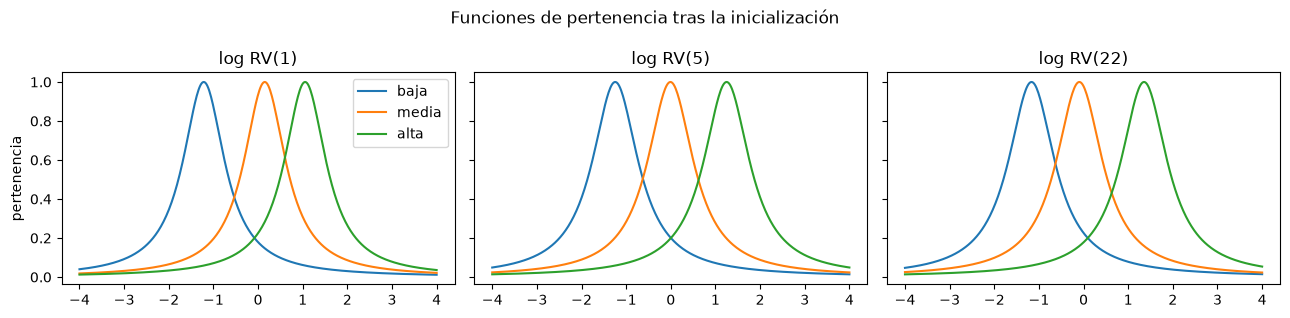

In [22]:
xs = torch.linspace(-4, 4, 400).unsqueeze(1).repeat(1, 3)
mus = modelo.pertenencia(xs).detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for k, var in enumerate(["log RV(1)", "log RV(5)", "log RV(22)"]):
    for j, et in enumerate(["baja", "media", "alta"]):
        axes[k].plot(xs[:, 0], mus[:, k, j], label=et)
    axes[k].set_title(var)
axes[0].set_ylabel("pertenencia"); axes[0].legend()
plt.suptitle("Funciones de pertenencia tras la inicialización")
plt.tight_layout()
plt.savefig("../results/figures/e5_pertenencia_inicial.png", dpi=150)
plt.show()

### Entrenamiento ANFIS

La parada temprana es en la época 0. El error de validación nunca bajó del valor inicial, sube desde la primera época y no vuelve. La línea roja está pegada al eje, y consecuentemente el mejor ANFIS es el ANFIS sin entrenar, es decir, HAR. Cada época que entrena, empeora en datos nuevos.

Mientras tanto, el error de entrenamiento sí baja (0,195 → 0,174), pero esto es un sobreajuste puro: los 135 parámetros están memorizando ruido de los 3.998 días de entrenamiento.

Como la parada temprana funciona, el modelo final que se guarda es el de la época 0.

La anchura media es idéntica a la inicial (~0,6), porque no llegó a entrenar.

In [23]:
from src.anfis import entrenar_anfis, predecir_anfis

modelo, hist_anfis = entrenar_anfis(modelo, partes_norm["train"], partes_norm["val"])

[anfis] Parada temprana en la época 200
[anfis] MSE de validación: 0.28884
[anfis] Anchura media final: 0.607


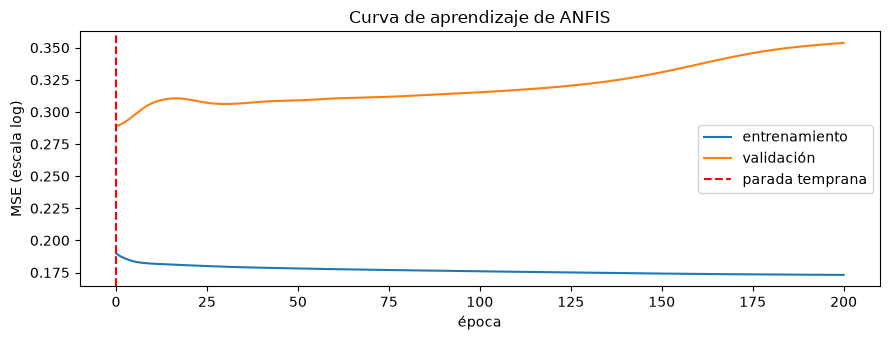

In [24]:
h = np.array(hist_anfis)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(h[:, 0], label="entrenamiento")
ax.plot(h[:, 1], label="validación")
ax.axvline(h[:, 1].argmin(), color="red", ls="--", label="parada temprana")
ax.set_xlabel("época"); ax.set_ylabel("MSE (escala log)")
ax.set_title("Curva de aprendizaje de ANFIS")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/e5_curva_aprendizaje.png", dpi=150)
plt.show()

NFIS aparece primero, pero con una diferencia mínimoHAR: RMSE 0,0958 vs 0,0968, QLIKE 0,1113 vs 0,1131. 

Esa diferencia mínima viene solo de la exponencial aplicada sobre predicciones logarítmicas casi iguales.
**ANFIS y HAR son en la práctica el mismo modelo aquí.**

Lo único destacable aquí es que ANFIS es algo mejor en estrés (QLIKE 0,3577 vs 0,3799).

In [25]:
y_hat_anfis = predecir_anfis(modelo, partes_norm["test"])

filas.append(evaluar(y_test, y_hat_anfis, idx_estres, "ANFIS (27 reglas)"))
tabla = tabla_resultados(filas)
tabla.to_csv("../results/tables/e5_anfis.csv")
tabla

,RMSE,MAE,QLIKE,RMSE_tranq,MAE_tranq,QLIKE_tranq,RMSE_estres,MAE_estres,QLIKE_estres
modelo,,,,,,,,,
ANFIS (27 reglas),0.0958,0.0551,0.1113,0.0717,0.0485,0.1033,0.3670,0.2595,0.3577
HAR,0.0968,0.0549,0.1131,0.0717,0.0483,0.1045,0.3757,0.2606,0.3799
Ingenuo 22d,0.1094,0.0648,0.1211,0.0792,0.0549,0.1130,0.4347,0.3721,0.3725
MLP (3-8-1),0.1024,0.0576,0.1418,0.0760,0.0505,0.1313,0.3960,0.2779,0.4683
Ingenuo 5d,0.1002,0.0637,0.1680,0.0846,0.0580,0.1619,0.3151,0.2413,0.3593
Ingenuo 1d,0.1410,0.0967,8.5075,0.1239,0.0902,8.7350,0.4008,0.2995,1.4337


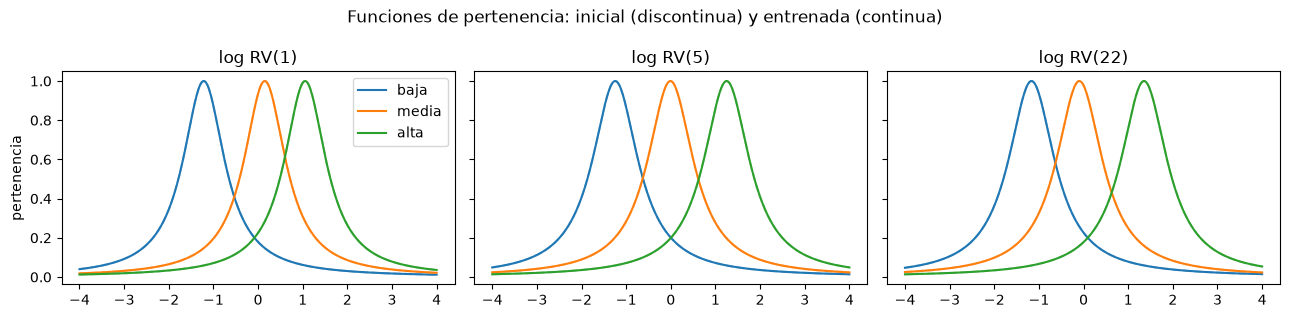

In [26]:
xs = torch.linspace(-4, 4, 400).unsqueeze(1).repeat(1, 3)
mus_fin = modelo.pertenencia(xs).detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for k, var in enumerate(["log RV(1)", "log RV(5)", "log RV(22)"]):
    for j, et in enumerate(["baja", "media", "alta"]):
        axes[k].plot(xs[:, 0], mus[:, k, j], ls="--", alpha=0.4, color=f"C{j}")
        axes[k].plot(xs[:, 0], mus_fin[:, k, j], color=f"C{j}", label=et)
    axes[k].set_title(var)
axes[0].set_ylabel("pertenencia"); axes[0].legend()
plt.suptitle("Funciones de pertenencia: inicial (discontinua) y entrenada (continua)")
plt.tight_layout()
plt.savefig("../results/figures/e5_pertenencia_comparacion.png", dpi=150)
plt.show()

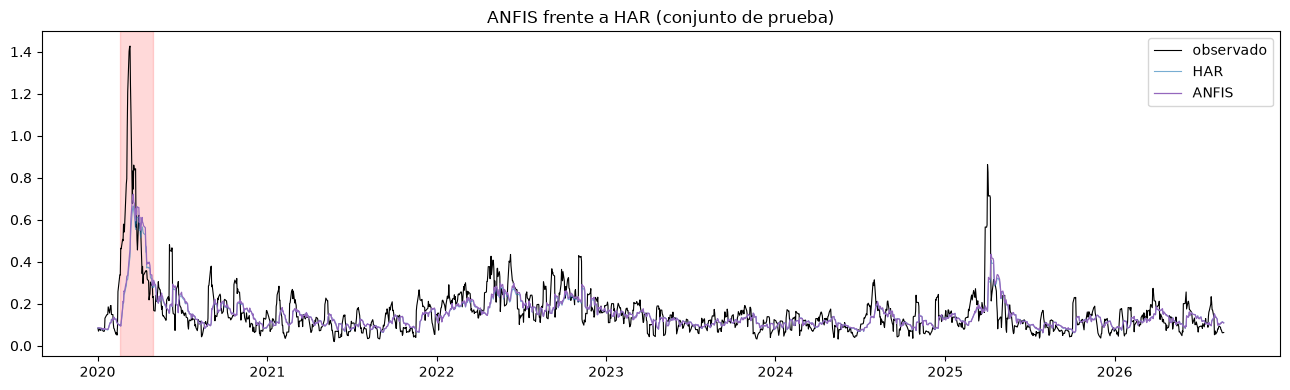

In [27]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, y_test, lw=0.8, color="black", label="observado")
ax.plot(test.index, y_hat_har, lw=0.8, color="tab:blue", alpha=0.6, label="HAR")
ax.plot(test.index, y_hat_anfis, lw=0.9, color="tab:purple", label="ANFIS")
ax.axvspan(idx_estres.min(), idx_estres.max(), color="red", alpha=0.15)
ax.set_title("ANFIS frente a HAR (conjunto de prueba)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/e5_anfis.png", dpi=150)
plt.show()

### Conclusión y resumen del modelo ANFIS

El entrenamiento se detiene en la época 0: el error de validación nunca mejora respecto del punto de partida. Como la inicialización sitúa el modelo en la solución de HAR, esto significa que ningún ajuste de los 135 parámetros mejora la predicción sobre datos no vistos. El error de entrenamiento sí desciende, lo que identifica el fenómeno como sobreajuste y no como fallo de optimización: el modelo aprende, pero aprende ruido.

Las funciones de pertenencia se mantienen inalteradas y la anchura media permanece en 0,607, así que no hay degeneración por aplanamiento de las campanas: sencillamente no ha habido movimiento.

En la tabla, ANFIS encabeza todas las métricas globales, pero por márgenes inferiores al 2% frente a HAR, e idénticos en el régimen tranquilo. Esa diferencia procede de la transformación exponencial aplicada sobre predicciones logarítmicas prácticamente iguales, no de una capacidad predictiva distinta. La única diferencia apreciable está en el periodo de estrés, donde ANFIS obtiene un QLIKE de 0,3577 frente al 0,3799 de HAR.

Leído junto al resultado del MLP, el diagnóstico es coherente: ni la no linealidad ni la partición difusa aportan precisión sobre una regresión lineal con estas tres entradas. La relación entre las volatilidades pasadas y la futura, en escala logarítmica, es esencialmente lineal, y toda la señal disponible ya la captura HAR.

### Prueba rápida antes de pasara a la conclusión final

La idea era descartar el exceso de capacidad reabajando de 2 a 3 conjuntos por varaibles. Es decir pasar a 8 reglas y 50 parametros (frente a los 27 y 135 de antes).

No obstante no mejora, por lo tanto el resultado no depende del número de reglas. Es decir, no es que el modelo fuera demasiado grande sino que no hay estructura no lineal que aprender. 

In [28]:
# --- Prueba: ANFIS con 2 conjuntos por variable ---
# 2^3 = 8 reglas, 8*4 + 2*3*3 = 50 parámetros frente a los 135 anteriores.
# Menos capacidad para sobreajustar: comprobamos si con esta configuración
# el entrenamiento sí mejora sobre validación.
from src.anfis import ANFIS, inicializar_por_percentiles, entrenar_anfis, predecir_anfis

modelo2 = ANFIS(n_entradas=3, n_conjuntos=2)
inicializar_por_percentiles(modelo2, partes_norm["train"], coef_har)
modelo2, hist2 = entrenar_anfis(modelo2, partes_norm["train"], partes_norm["val"])

print(f"\nReglas: {modelo2.n_reglas} | "
      f"Parámetros: {sum(p.numel() for p in modelo2.parameters())}")
print(f"Época del mínimo de validación: {np.array(hist2)[:, 1].argmin()}")

[anfis] Centros por variable:
[[-1.216  1.054]
 [-1.245  1.25 ]
 [-1.166  1.354]]
[anfis] Anchuras: [1.135 1.248 1.26 ]
[anfis] Parada temprana en la época 200
[anfis] MSE de validación: 0.28917
[anfis] Anchura media final: 1.214

Reglas: 8 | Parámetros: 50
Época del mínimo de validación: 0


In [29]:
y_hat_anfis2 = predecir_anfis(modelo2, partes_norm["test"])

filas.append(evaluar(y_test, y_hat_anfis2, idx_estres, "ANFIS (8 reglas)"))
tabla = tabla_resultados(filas)
tabla.to_csv("../results/tables/e5_anfis.csv")
tabla

,RMSE,MAE,QLIKE,RMSE_tranq,MAE_tranq,QLIKE_tranq,RMSE_estres,MAE_estres,QLIKE_estres
modelo,,,,,,,,,
ANFIS (8 reglas),0.0958,0.0551,0.1113,0.0717,0.0485,0.1034,0.3671,0.2590,0.3568
ANFIS (27 reglas),0.0958,0.0551,0.1113,0.0717,0.0485,0.1033,0.3670,0.2595,0.3577
HAR,0.0968,0.0549,0.1131,0.0717,0.0483,0.1045,0.3757,0.2606,0.3799
Ingenuo 22d,0.1094,0.0648,0.1211,0.0792,0.0549,0.1130,0.4347,0.3721,0.3725
MLP (3-8-1),0.1024,0.0576,0.1418,0.0760,0.0505,0.1313,0.3960,0.2779,0.4683
Ingenuo 5d,0.1002,0.0637,0.1680,0.0846,0.0580,0.1619,0.3151,0.2413,0.3593
Ingenuo 1d,0.1410,0.0967,8.5075,0.1239,0.0902,8.7350,0.4008,0.2995,1.4337
